<a href="https://colab.research.google.com/github/shashank08-spec/Time-Series-Modelling/blob/main/Time_series_model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import itertools

Loading Dataset

In [17]:
data = pd.read_csv("/content/oil_prices_2426.csv")

print(data.head())
print(data.info())

data['date'] = pd.to_datetime(data['date'])
data.set_index('date', inplace=True)

data = data.sort_index()

         date  price (dollars)
0  21-09-2024            32.10
1  22-09-2024            32.25
2  23-09-2024            31.07
3  24-09-2024            31.50
4  25-09-2024            32.21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             500 non-null    object 
 1   price (dollars)  500 non-null    float64
dtypes: float64(1), object(1)
memory usage: 7.9+ KB
None


/tmp/ipykernel_551/1876782225.py:6: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data['date'] = pd.to_datetime(data['date'])


Basic EDA

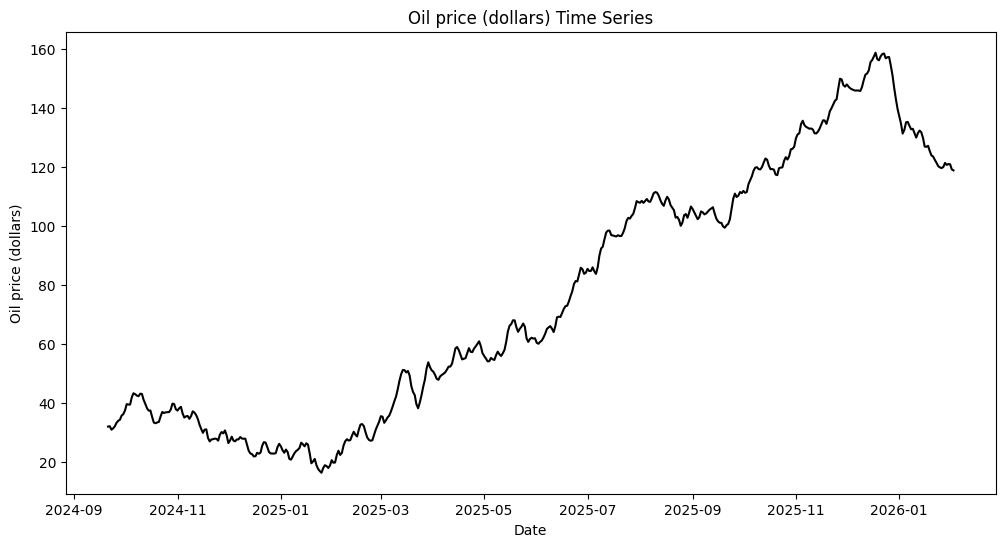

In [18]:
plt.figure(figsize=(12,6))
plt.plot(data['price (dollars)'], color='black')
plt.title("Oil price (dollars) Time Series")
plt.xlabel("Date")
plt.ylabel("Oil price (dollars)")
plt.show()

Rolling Mean and Rolling Std

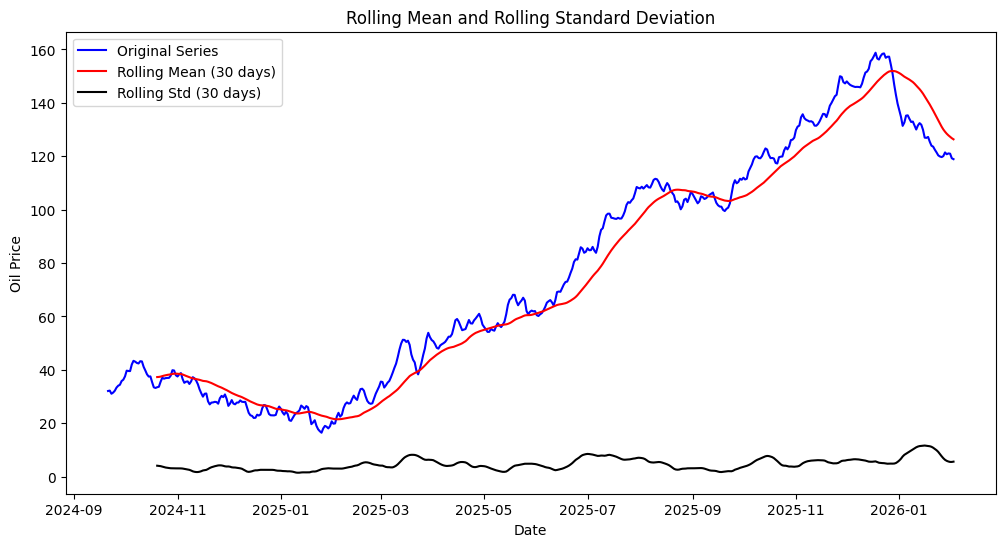

In [51]:
rolling_mean = data['price (dollars)'].rolling(window=30).mean()

rolling_std = data['price (dollars)'].rolling(window=30).std()

plt.figure(figsize=(12,6))

plt.plot(data['price (dollars)'], label="Original Series", color="blue")

plt.plot(rolling_mean, label="Rolling Mean (30 days)", color="red")

plt.plot(rolling_std, label="Rolling Std (30 days)", color="black")

plt.legend()

plt.title("Rolling Mean and Rolling Standard Deviation")

plt.xlabel("Date")
plt.ylabel("Oil Price")

plt.show()

ADF Test

In [19]:
result = adfuller(data['price (dollars)' ])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.5462340182601634
p-value: 0.8826741397403068


Data Stationary

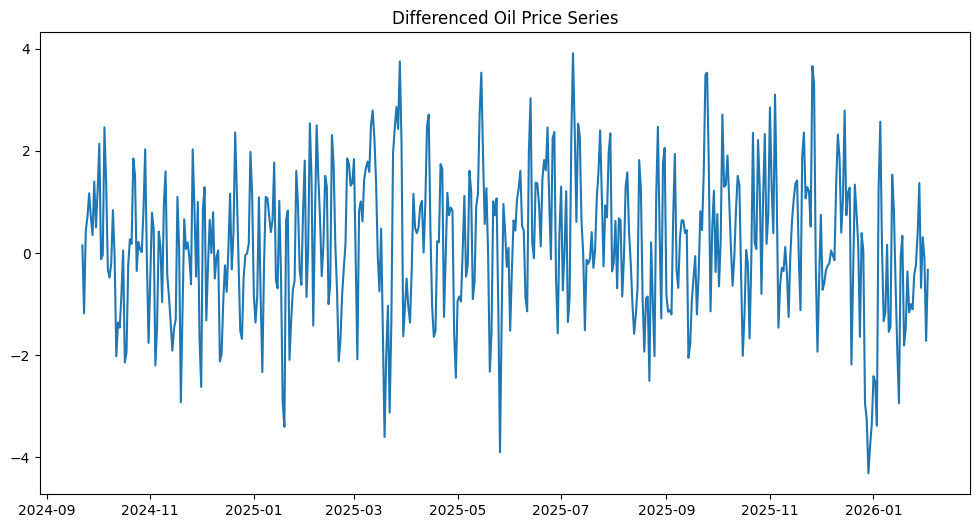

ADF Statistic: -4.541460173486703
ADF p-value after differencing: 0.00016536459860957148


In [20]:
data_diff = data['price (dollars)'].diff().dropna()
plt.figure(figsize=(12,6))
plt.plot(data_diff)
plt.title("Differenced Oil Price Series")
plt.show()
result = adfuller(data_diff)
print("ADF Statistic:", result[0])
print("ADF p-value after differencing:", result[1])


ACF and PACF Plots

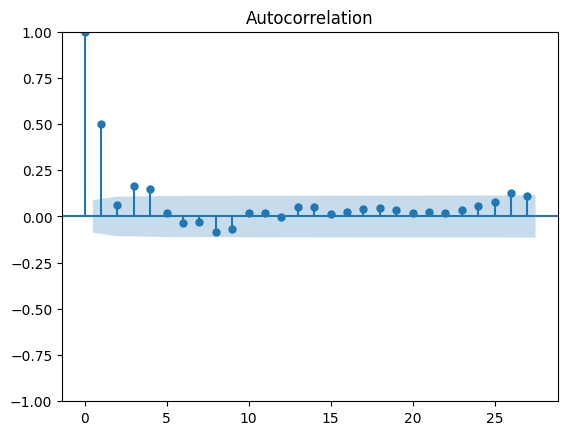

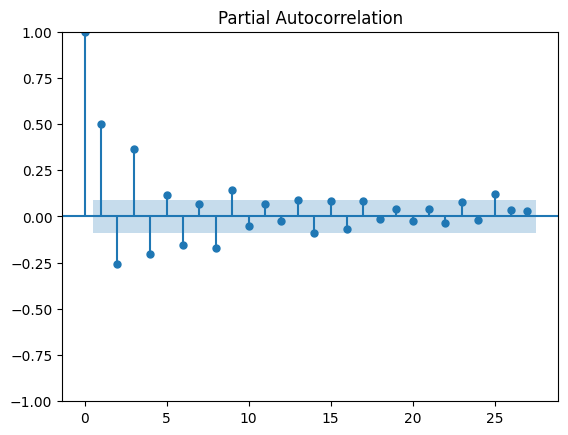

In [21]:
plot_acf(data_diff)
plot_pacf(data_diff)
plt.show()

AIC Grid Search

In [22]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

p = range(0,8)
d = range(0,2)
q = range(0,8)

pdq = list(itertools.product(p,d,q))

best_aic = float("inf")
best_order = None

for param in pdq:

    try:

        model = ARIMA(train['price (dollars)'], order=param)
        results = model.fit()

        if results.aic < best_aic:

            best_aic = results.aic
            best_order = param

    except:
        continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

Best ARIMA order: (3, 1, 4)
Best AIC: 1125.3801551359672


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
arima_model = ARIMA(train['price (dollars)'], order=(3,1,4))
arima_results = arima_model.fit()

print(arima_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:        price (dollars)   No. Observations:                  400
Model:                 ARIMA(3, 1, 4)   Log Likelihood                -554.690
Date:                Thu, 12 Mar 2026   AIC                           1125.380
Time:                        01:48:46   BIC                           1157.292
Sample:                    09-21-2024   HQIC                          1138.019
                         - 10-25-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3653      0.082      4.444      0.000       0.204       0.526
ar.L2          0.2242      0.110      2.029      0.042       0.008       0.441
ar.L3         -0.8148      0.086     -9.491      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Split Data into Training and Testing Sets for ARIMA

In [24]:
train_size_arima = int(len(data) * 0.8)
train = data.iloc[:train_size_arima]
test = data.iloc[train_size_arima:]

print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")

Training data points: 400
Testing data points: 100


Residual Diagnostics

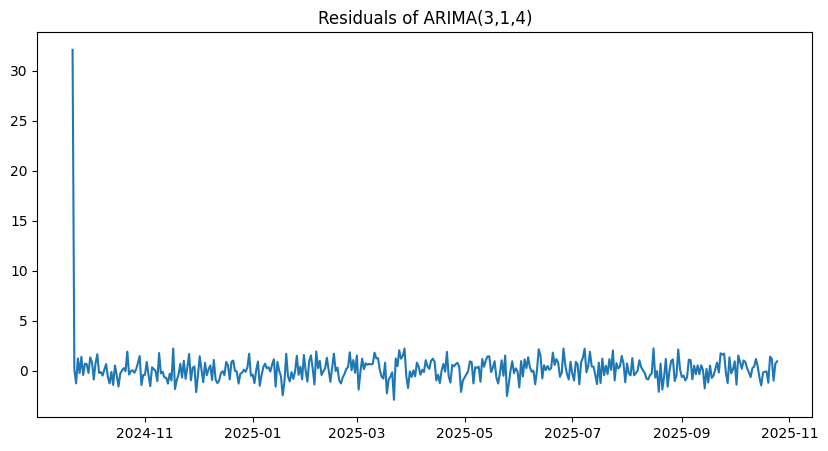

In [25]:
residuals = arima_results.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals of ARIMA(3,1,4)")
plt.show()

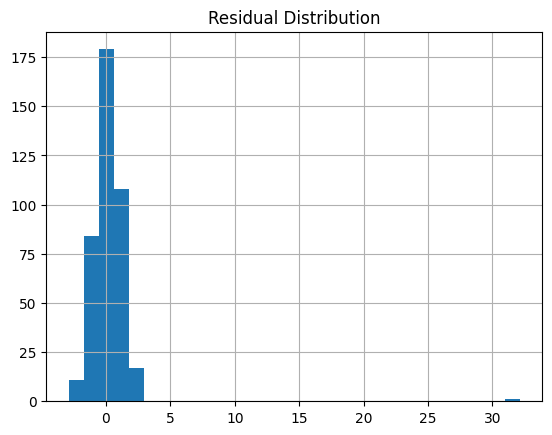

In [26]:
residuals.hist(bins=30)
plt.title("Residual Distribution")
plt.show()

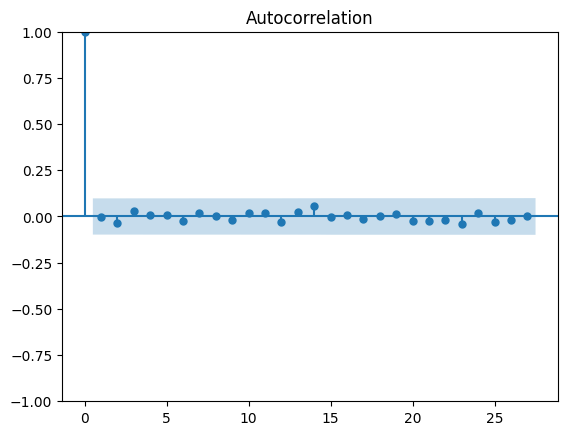

In [27]:
plot_acf(residuals)
plt.show()

Evaluate Model Performance (RMSE)

In [28]:
forecast_test = arima_results.forecast(steps=len(test))
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['price (dollars)'], forecast_test))

print("RMSE:", rmse)

RMSE: 18.6408875169387


Plot Prediction vs Actual

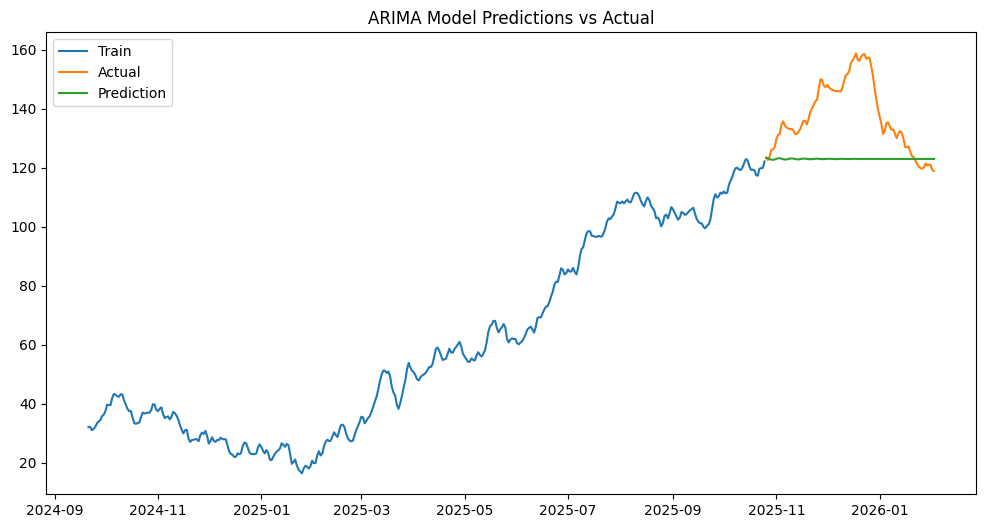

In [29]:
plt.figure(figsize=(12,6))

plt.plot(train['price (dollars)'], label='Train')
plt.plot(test['price (dollars)'], label='Actual')
plt.plot(test.index, forecast_test, label='Prediction')

plt.legend()
plt.title("ARIMA Model Predictions vs Actual")
plt.show()

Forecasting the 24 Months Into the Future

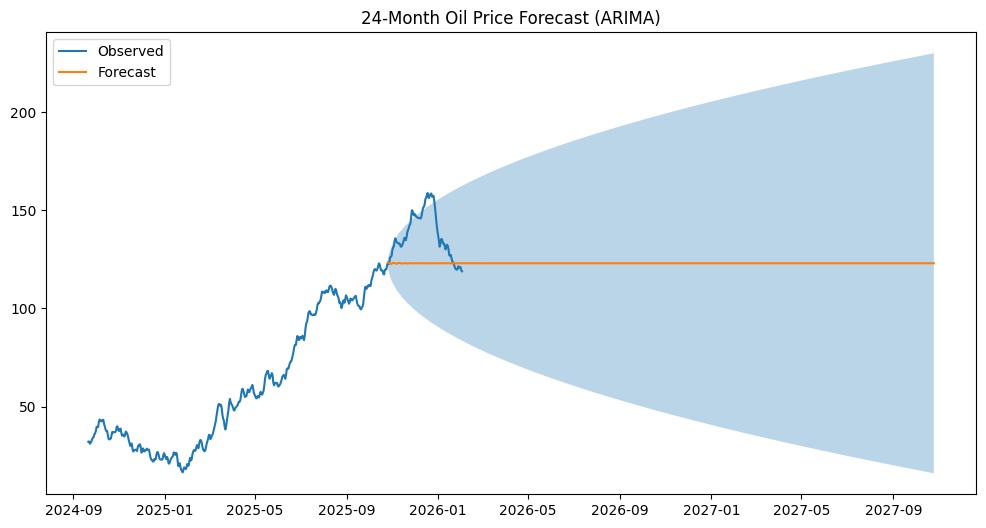

In [30]:
forecast = arima_results.get_forecast(steps=730)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()
plt.figure(figsize=(12,6))

plt.plot(data['price (dollars)'], label="Observed")
plt.plot(forecast_mean, label="Forecast")

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("24-Month Oil Price Forecast (ARIMA)")
plt.show()

PART 2

Normalize the Data

In [31]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data[['price (dollars)']])

Time Series Sequence

In [32]:
def create_dataset(dataset, window=30):

    X, y = [], []

    for i in range(len(dataset)-window):
        X.append(dataset[i:(i+window), 0])
        y.append(dataset[i+window, 0])

    return np.array(X), np.array(y)

In [33]:
window_size = 30

X, y = create_dataset(scaled_data, window_size)

Train/Test Spilt

In [34]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

Reshape Data for LSTM

In [35]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

Build the LSTM Model

In [36]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, input_shape=(window_size,1)))

lstm_model.add(Dense(1))

lstm_model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train the Model

In [37]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1007 - val_loss: 0.0091
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0086 - val_loss: 0.0102
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0049 - val_loss: 0.0077
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0025 - val_loss: 0.0044
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0013 - val_loss: 0.0022
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.5261e-04 - val_loss: 0.0057
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 8.4349e-04 - val_loss: 0.0042
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 7.9819e-04 - val_loss: 0.0052
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.6589e-04 - val_loss: 0.0033
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.5707e-04 - val_loss: 0.0035
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 7.4734e-04 - val_loss: 0.0031
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 

Plot Training Loss

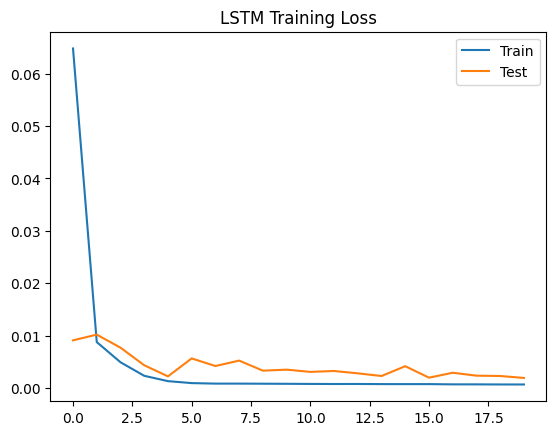

In [38]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("LSTM Training Loss")
plt.legend(["Train","Test"])
plt.show()

Make Predictions

In [39]:
predictions = lstm_model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


Evaluate Model

In [40]:
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, predictions))

print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 6.260801749456946


Plot Predictions vs Actual

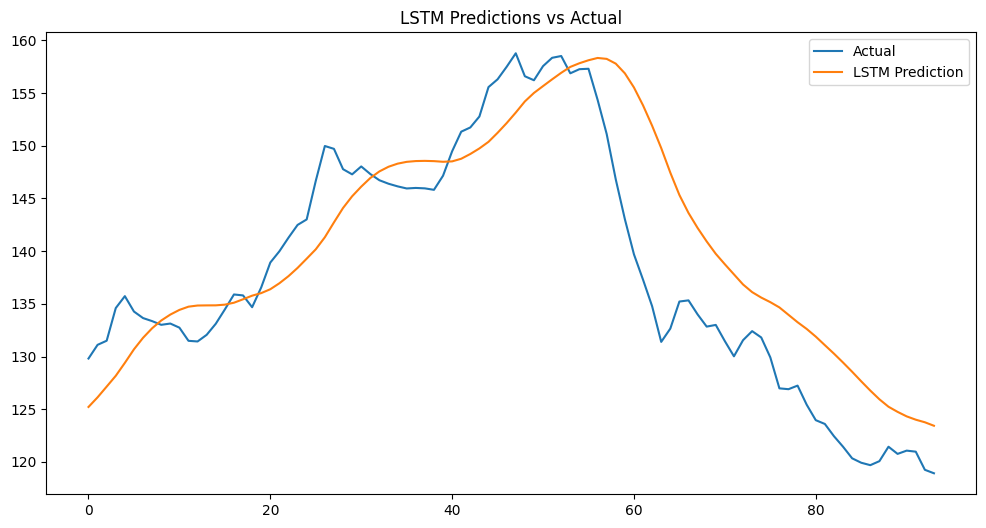

In [41]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="LSTM Prediction")

plt.legend()
plt.title("LSTM Predictions vs Actual")
plt.show()

Forecast 24 Months

In [42]:
future_steps = 730

last_window = scaled_data[-window_size:]

future_predictions = []

current_window = last_window.copy()

for i in range(future_steps):
    current_window_reshaped = current_window.reshape((1, window_size, 1))
    next_pred = lstm_model.predict(current_window_reshaped)
    future_predictions.append(next_pred[0,0])
    current_window = np.append(current_window[1:], next_pred)

future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

Plot LSTM Forecast

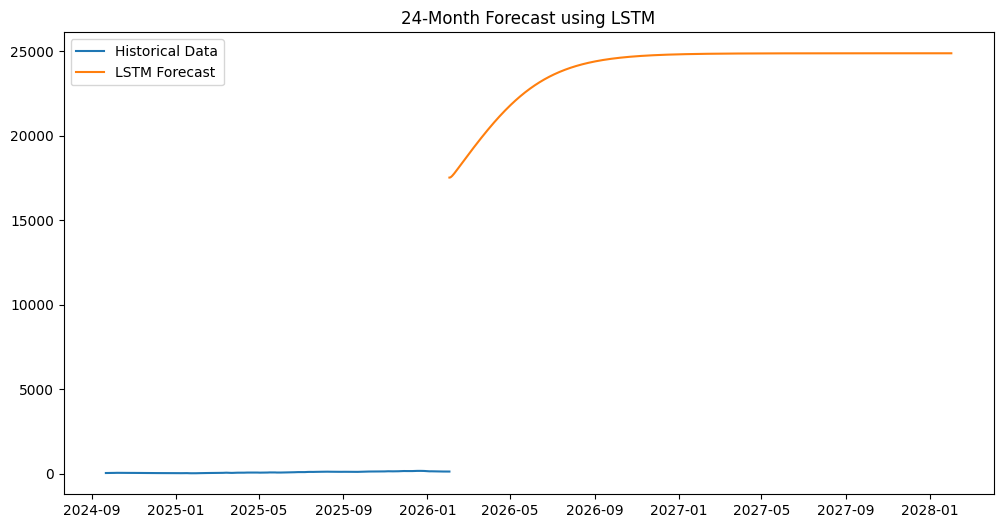

In [43]:
plt.figure(figsize=(12,6))

plt.plot(data['price (dollars)'], label="Historical Data")

future_dates = pd.date_range(
    start=data.index[-1],
    periods=730,
    freq="D"
)

future_predictions = np.array(future_predictions)
future_predictions = scaler.inverse_transform(
    future_predictions.reshape(-1,1)
)
future_predictions = future_predictions.flatten()

plt.plot(future_dates, future_predictions, label="LSTM Forecast")

plt.legend()
plt.title("24-Month Forecast using LSTM")

plt.show()

Evaluation Metrics

In [44]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, predictions)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae)

LSTM RMSE: 6.260801749456946
LSTM MAE: 4.888133359868475


Future Date Index

In [45]:
future_dates = pd.date_range(
    start=data.index[-1],
    periods=730,
    freq="D"
)

Plot ARIMA vs LSTM

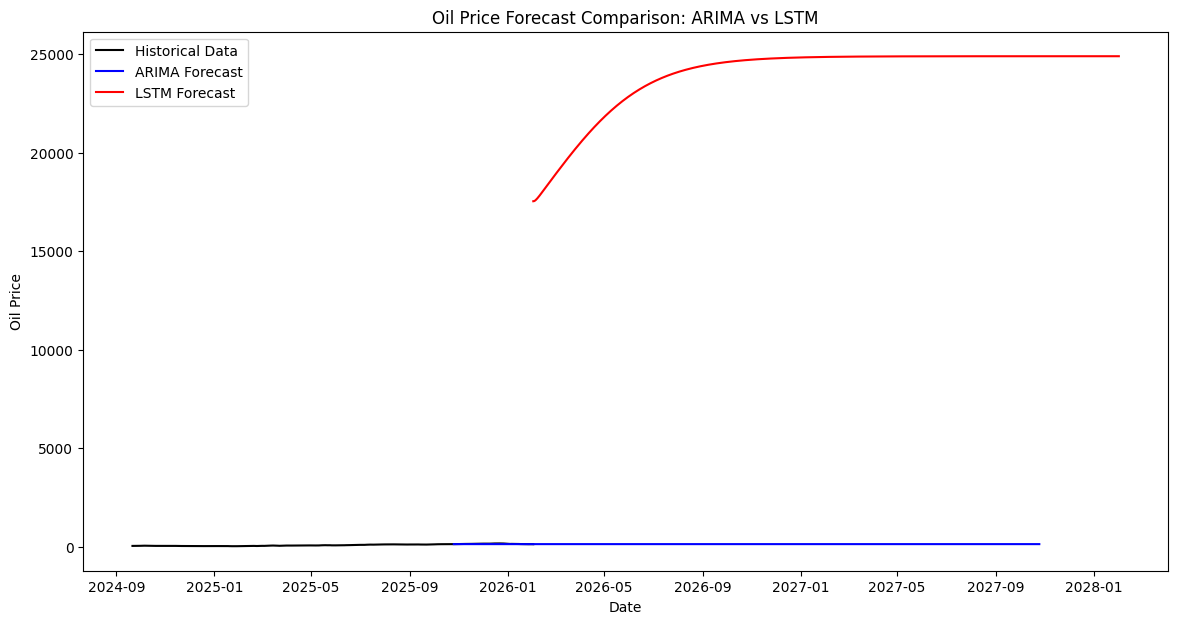

In [46]:
plt.figure(figsize=(14,7))

# Historical data
plt.plot(data['price (dollars)'], label="Historical Data", color="black")

# ARIMA forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="ARIMA Forecast",
    color="blue"
)

# LSTM forecast
plt.plot(
    future_dates,
    future_predictions,
    label="LSTM Forecast",
    color="red"
)

plt.legend()

plt.title("Oil Price Forecast Comparison: ARIMA vs LSTM")

plt.xlabel("Date")
plt.ylabel("Oil Price")

plt.show()

ARIMA confidence intervals

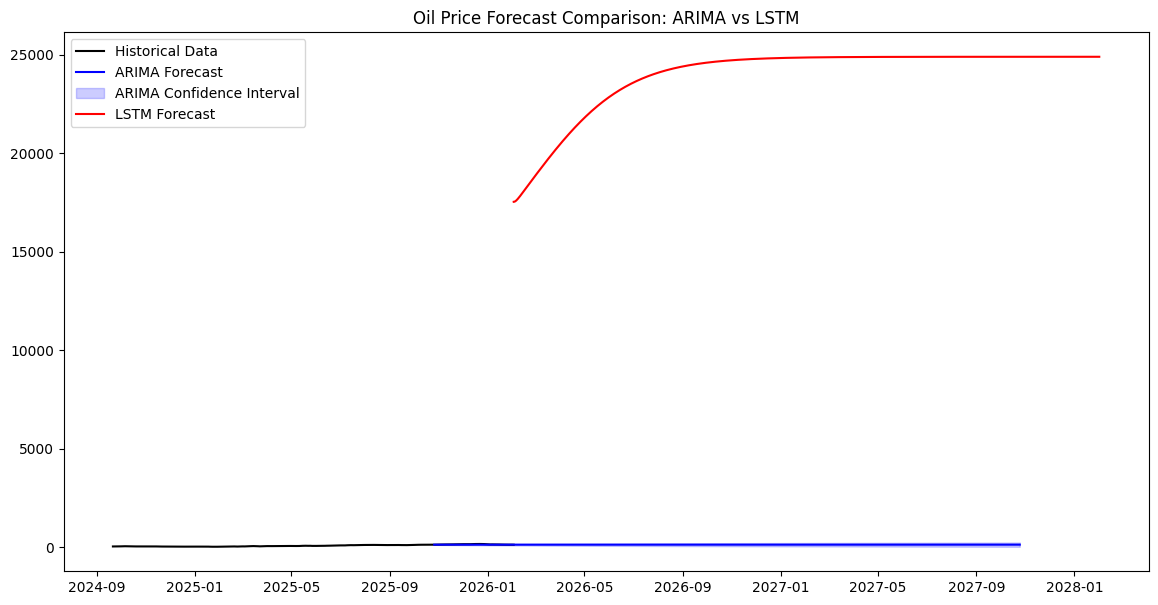

In [47]:
plt.figure(figsize=(14,7))

plt.plot(data['price (dollars)'], label="Historical Data", color="black")

plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="ARIMA Forecast",
    color="blue"
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    alpha=0.2,
    color="blue",
    label="ARIMA Confidence Interval"
)

plt.plot(
    future_dates,
    future_predictions,
    label="LSTM Forecast",
    color="red"
)

plt.legend()

plt.title("Oil Price Forecast Comparison: ARIMA vs LSTM")

plt.show()